# ✍️ P2 — Style Transfer Prompts
## prompt-engineering-lab

**Goal:** Measure how well different prompt strategies transfer writing style across 10 target styles.

| | |
|---|---|
| **Styles** | Journalism, Academic, Legal, Executive, Casual, Storytelling, Technical, Marketing, Medical, Minimalist |
| **Models** | GPT-4o-mini, GPT-4o, Claude Haiku, Claude Sonnet 4.6, Mistral 7B, Llama 3 8B |
| **Strategies** | A=Direct instruction · B=Role prompting · C=Contrastive DO/DON'T |
| **Metrics** | FK Grade · Formality Score · TTR · Sentiment Delta · Compression Ratio · LLM Judge |

---

## 0. Setup

In [1]:
# !pip install openai anthropic pandas numpy matplotlib

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Set API keys (or use environment variables)
# os.environ['OPENAI_API_KEY']    = 'sk-...'
# os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'

print('Setup complete')

Setup complete


## 1. Preview Source Texts

In [2]:
texts = pd.read_csv('data/source_texts.csv')
print(f'{len(texts)} source texts across domains: {texts["domain"].tolist()}')
texts[['id','domain','word_count']]

5 source texts across domains: ['science', 'business', 'health', 'technology', 'environment']


,id,domain,word_count
0,T01,science,120
1,T02,business,115
2,T03,health,108
3,T04,technology,125
4,T05,environment,118


In [3]:
# Preview a text
print(texts[texts['id']=='T02']['text'].values[0])

Our company had a really rough third quarter. Revenue dropped by 18 percent compared to the same period last year, which was mostly because of supply chain problems that made it hard to get products to customers on time. We also lost two big clients who went with cheaper competitors. The good news is that we have fixed most of the supply chain issues now and signed three new contracts worth a combined 4 million dollars. Management thinks we will be back to normal growth by Q1 next year if things keep going the way they are.


## 2. Preview Prompt Library

In [4]:
from run_experiment import load_prompts
from pathlib import Path

prompts = load_prompts(Path('prompts/prompts.txt'))
print(f'{len(prompts)} prompts loaded\n')
for pid, meta in prompts.items():
    preview = meta['template'][:70].replace('\n',' ')
    print(f'  [{pid}] {meta["style"]:14s} {meta["strategy"]:22s}  "{preview}..."')

30 prompts loaded

  [S01A] journalism     direct_instruction      "Rewrite the following text in the style of a professional news article..."
  [S01B] journalism     role_prompting          "You are a senior reporter at a major national newspaper. Your editor h..."
  [S01C] journalism     contrastive             "Rewrite the text below as a news article.  DO: Lead with the most news..."
  [S02A] academic       direct_instruction      "Rewrite the following text in formal academic prose suitable for a pee..."
  [S02B] academic       role_prompting          "You are a tenured professor writing for an academic journal. Transform..."
  [S02C] academic       contrastive             "Transform the text into academic writing.  DO: Use formal register. He..."
  [S03A] legal          direct_instruction      "Rewrite the following text in formal legal language as it might appear..."
  [S03B] legal          role_prompting          "You are a senior attorney drafting a formal legal document. Rewr

## 5. Explore Results

In [5]:
df = pd.read_csv('results/results.csv')
df_clean = df[df['error'].isna() | (df['error'] == '')].copy()

# Formality by style — this is the core finding
formality = df_clean.groupby('style')['formality_score'].mean().sort_values(ascending=False)
print('Formality ranking by style:')
for style, score in formality.items():
    bar = '█' * int(score * 30)
    print(f'  {style:15s}  {bar}  {score:.3f}')

Formality ranking by style:
  legal            ████████████████  0.563
  academic         ███████████████  0.526
  medical          ███████████████  0.515
  technical        ███████████████  0.504
  journalism       ███████████████  0.503
  executive        ██████████████  0.475
  storytelling     █████████████  0.465
  minimalist       █████████████  0.459
  marketing        █████████  0.309
  casual           ████████  0.286


In [6]:
# Strategy comparison — which strategy transfers style best?
strat = df_clean.groupby(['strategy','style'])[['formality_score','fk_grade']].mean().round(3)
strat

formality_score  fk_grade
strategy           style                                  
contrastive        academic                0.531    18.993
                   casual                  0.310     5.300
                   executive               0.475    13.357
                   journalism              0.497    12.348
                   legal                   0.589    16.706
                   marketing               0.309     8.441
                   medical                 0.518    16.743
                   minimalist              0.457     9.124
                   storytelling            0.478     8.051
                   technical               0.505    14.911
direct_instruction academic                0.526    18.920
                   casual                  0.279     5.705
                   executive               0.482    15.834
                   journalism              0.512    13.613
                   legal                   0.562    30.729
                   marketing               0.320     8.408
                   medical                 0.511    18.384
                   minimalist              0.452     8.854
                   storytelling            0.460     7.213
                   technical               0.504    15.941
role_prompting     academic                0.521    18.024
                   casual                  0.269     8.714
                   executive               0.467    12.761
                   journalism              0.499    14.326
                   legal                   0.539    21.291
                   marketing               0.298     7.857
                   medical                 0.516    18.006
                   minimalist              0.468     7.845
                   storytelling            0.456    10.780
                   technical               0.504    16.068

In [7]:
# Metric deltas — how much does each style shift the text?
if 'delta_fk_grade' in df_clean.columns:
    deltas = df_clean.groupby('style')[['delta_fk_grade','delta_formality','delta_sentiment','delta_ttr']].mean().round(3)
    deltas.style.background_gradient(cmap='RdYlGn', axis=None)

## 6. Generate Charts

In [8]:
from visualize import generate_all_charts
generate_all_charts()


 Generating charts from results\results.csv...
  900 rows | 6 models | 10 styles

  ✓ results\chart_formality_heatmap.png
  ✓ results\chart_fk_grade.png
  ✓ results\chart_strategy_comparison.png
  ✓ results\chart_delta_radar.png


C:\Users\HomePC\prompt-engineering-lab\projects\style-transfer-prompts\visualize.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp.index, rotation=20, ha="right")


  ✓ results\chart_compression.png


C:\Users\HomePC\prompt-engineering-lab\projects\style-transfer-prompts\visualize.py:331: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(comp.index, rotation=30, ha="right", fontsize=7)


  ✓ results\charts.png  <- README hero

 All charts saved to results/


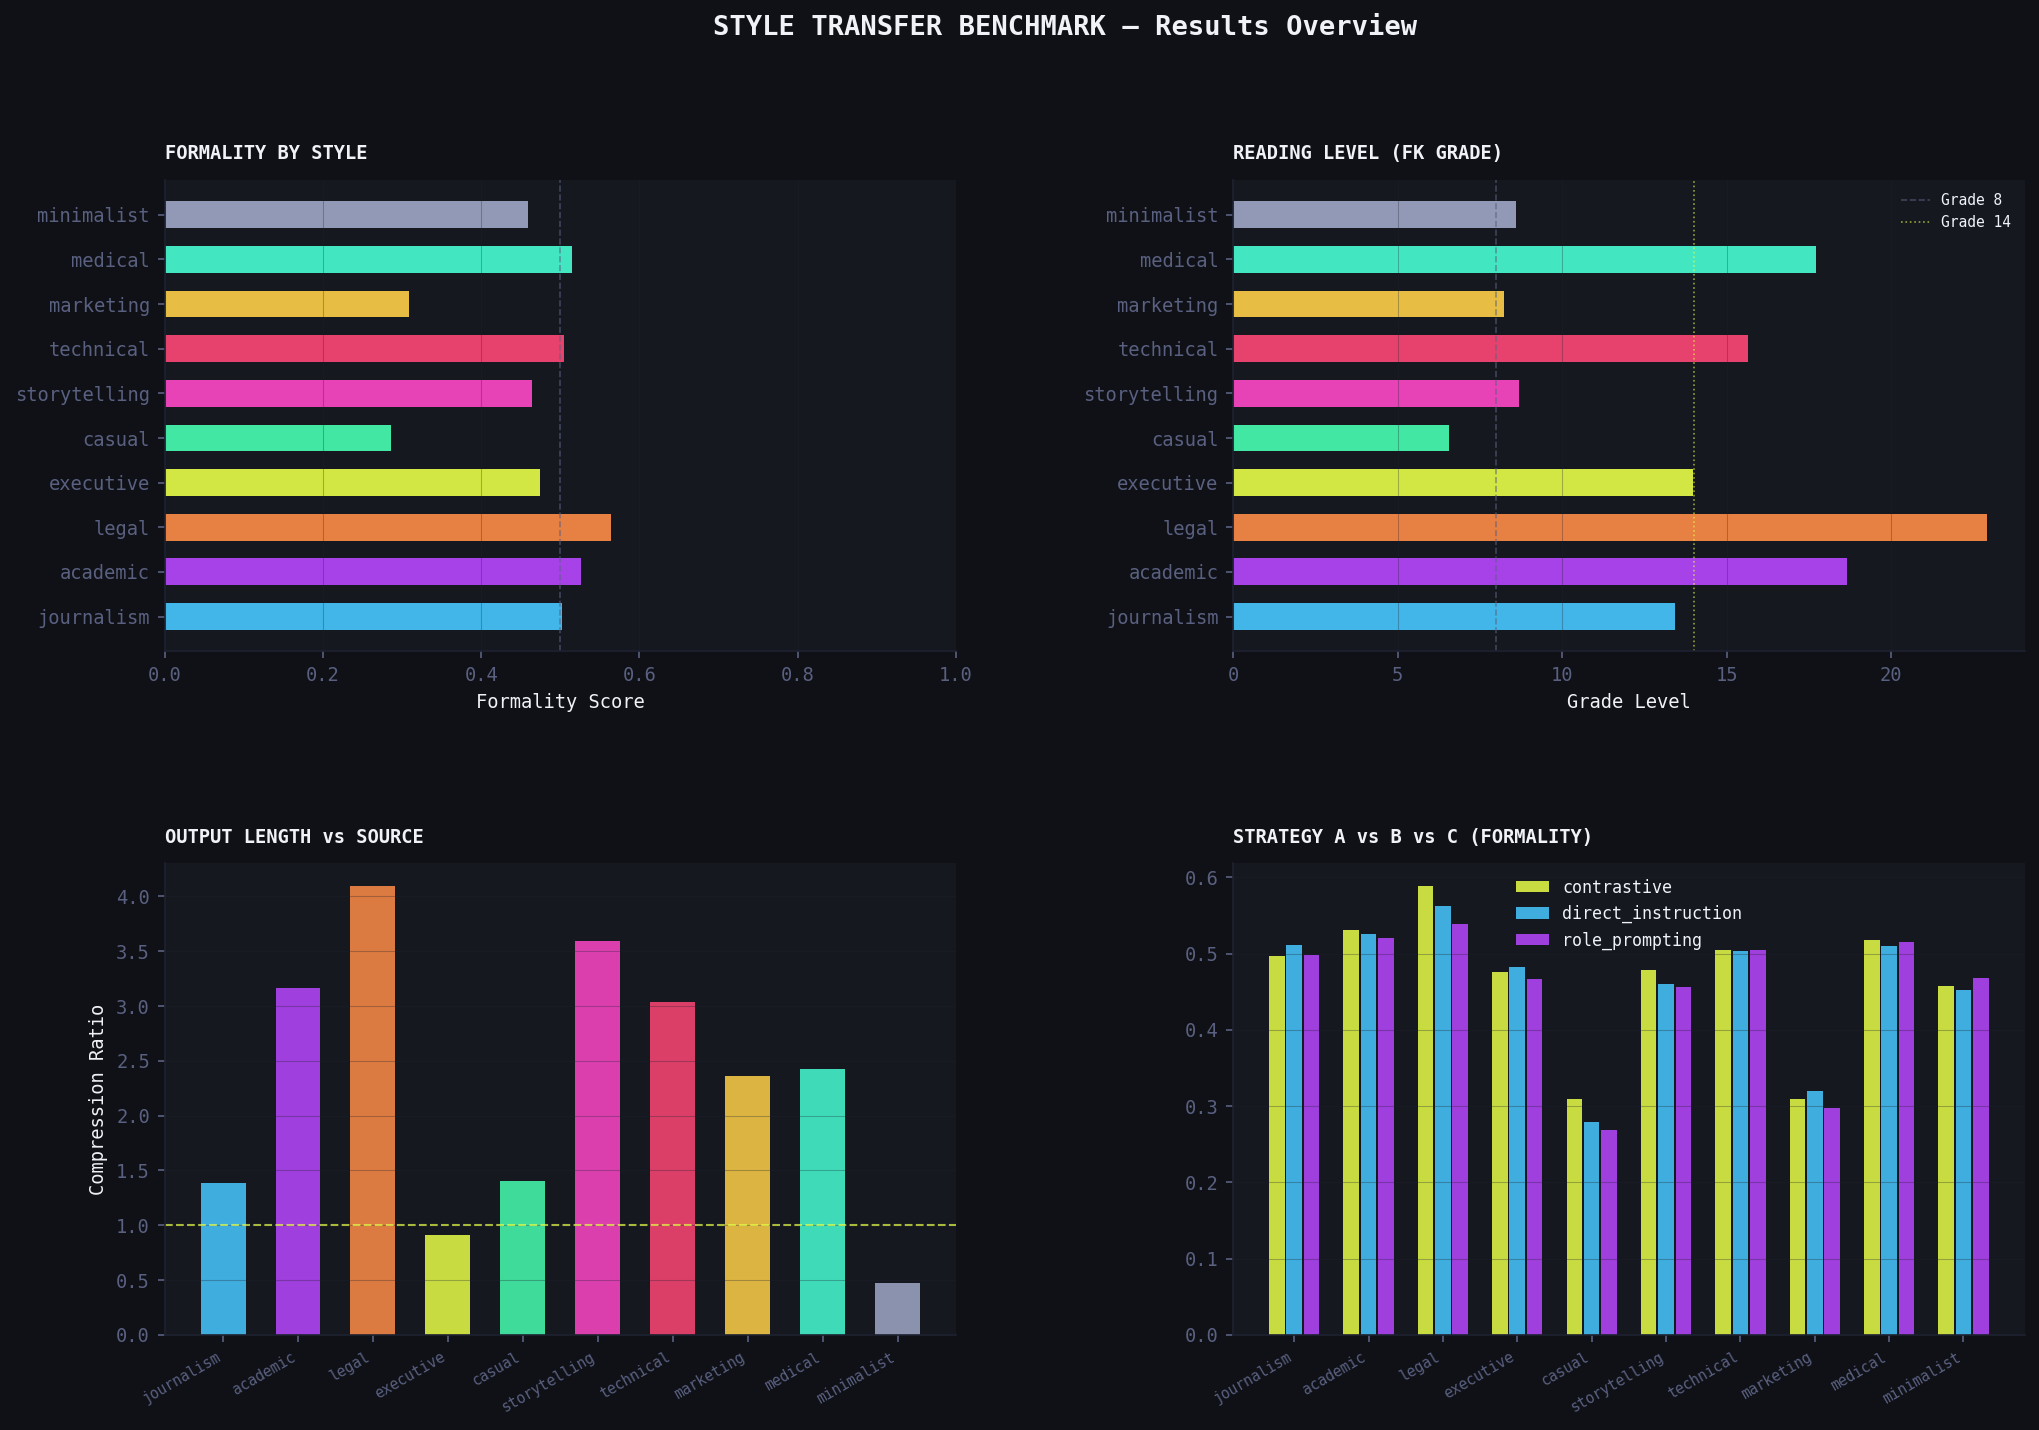

In [9]:
from IPython.display import Image
Image('results/charts.png')

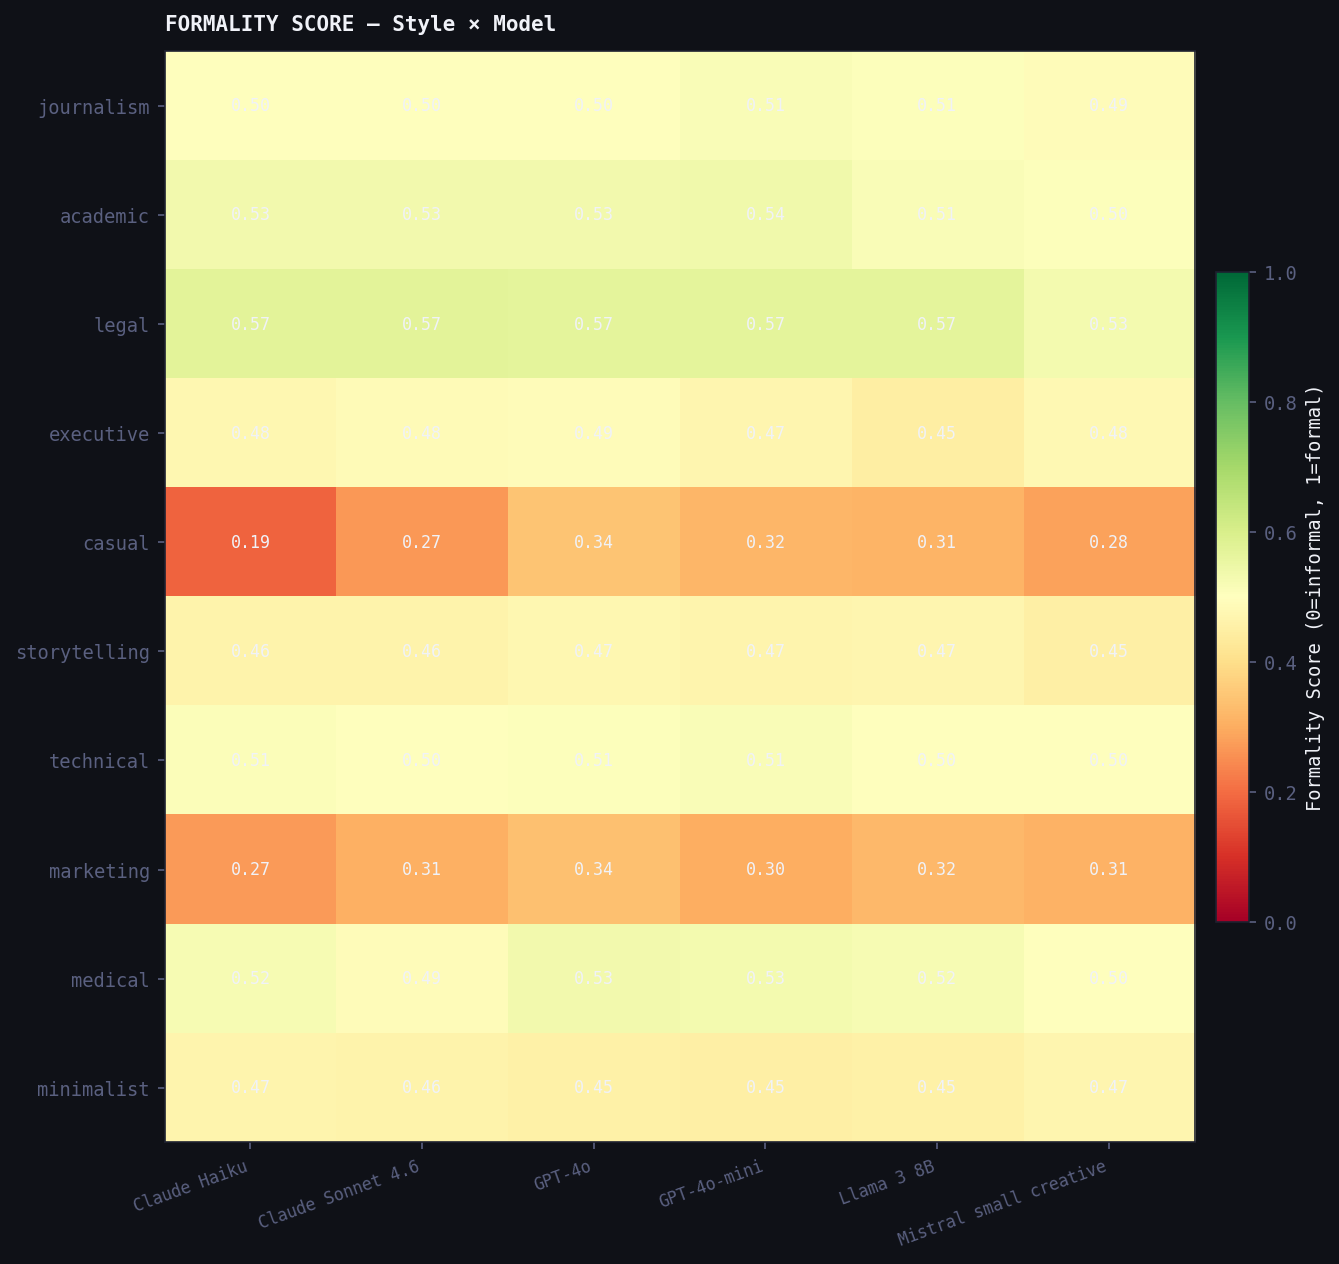

In [10]:
Image('results/chart_formality_heatmap.png')

## 7. Generate Side-by-Side Gallery

In [11]:
from gallery import generate_gallery
gallery_path = generate_gallery()
print(f'Gallery: {gallery_path}')
# Open results/gallery.html in your browser to see all outputs side by side

Gallery saved: results\gallery.html
Gallery: results\gallery.html


## 8. Key Findings

Fill in after running the experiment:

1. **Highest formality shift:** `legal` — delta_formality = +0.129
2. **Most casual output:** `casual` — delta_formality = -0.149
3. **Most readable style:** `casual` — FK grade 6.6
4. **Most complex style:** `legal` — FK grade 22.9
5. **Most compressed output:** `minimalist` — 0.48x source length
6. **Most expanded output:** `legal` — 4.10x source length
7. **Best prompt strategy:** `contrastive` — avg formality 0.467
8. 5. **Best model for style transfer:** Run with --llm-judge to score style adherence per model

---
*See `results/gallery.html` for full side-by-side comparison of all outputs.*